Lab 5
Jack Schwyn

In [168]:
#Importing all relevant libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import metrics
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import roc_auc_score

In [169]:
df = pd.read_csv("Telco-Customer-Churn.csv", skipinitialspace = True) #Importing original dataset.
df = df.dropna() #Remove any "NAs."
df #Show data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [170]:
#Summary statistics for monthly charges
mean = df.MonthlyCharges.mean() #Mean
median = df.MonthlyCharges.median() #Median
max = df.MonthlyCharges.max() #Max
min = df.MonthlyCharges.min() #Min
#Print statements
print("Monthly Charges:")
print("Mean: ", mean)
print("Median: ", median)
print("Max: ", max)
print("Min: ", min)

Monthly Charges:
Mean:  64.79820819112628
Median:  70.35
Max:  118.75
Min:  18.25


Right now, we cannot give a basic summary for Churn, because it is a categorial variable.
We will have to encode the categorial variables.

In [171]:
#Encoding categorial vairables (yes or no -> 1 or 0)
df.Partner= df.Partner.astype('category').cat.codes
df.Dependents = df.Dependents.astype('category').cat.codes
df.PhoneService = df.PhoneService.astype('category').cat.codes
df.PaymentMethod = df.PaymentMethod.astype('category').cat.codes
df.MultipleLines = df.MultipleLines.astype('category').cat.codes
df.InternetService = df.InternetService.astype('category').cat.codes
df.OnlineSecurity = df.OnlineSecurity.astype('category').cat.codes
df.OnlineBackup = df.OnlineBackup.astype('category').cat.codes
df.DeviceProtection = df.DeviceProtection.astype('category').cat.codes
df.TechSupport = df.TechSupport.astype('category').cat.codes
df.StreamingTV = df.StreamingTV.astype('category').cat.codes
df.StreamingMovies = df.StreamingMovies.astype('category').cat.codes
df.Contract = df.Contract.astype('category').cat.codes
df.PaperlessBilling= df.PaperlessBilling.astype('category').cat.codes
df.Churn = df.Churn.astype('category').cat.codes
df.gender = df.gender.astype('category').cat.codes
df.customerID = df.customerID.astype('category').cat.codes
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5365,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,3953,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,2558,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,5524,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,6500,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,4843,1,0,1,1,24,1,2,0,2,...,2,2,2,2,1,1,3,84.80,1990.50,0
7039,1524,0,0,1,1,72,1,2,1,0,...,2,0,2,2,1,1,1,103.20,7362.90,0
7040,3358,0,0,1,1,11,0,1,0,2,...,0,0,0,0,0,1,2,29.60,346.45,0
7041,5923,1,1,1,0,4,1,2,1,0,...,0,0,0,0,0,1,3,74.40,306.60,1


By categorizing the data (strings to integers), we are able to properly split the dataset into training and testing.

In [172]:
#Summary statistic for Churn (1 = yes, 0 = no)
mean = df.Churn.mean() #Mean
median = df.Churn.median() #Median
mode = df.Churn.mode() #Mode
#Print statements
print("Churn:")
print("Mean: ", mean)
print("Median: ", median)
print("Mode: ", mode)

Churn:
Mean:  0.26578498293515357
Median:  0.0
Mode:  0    0
Name: Churn, dtype: int8


From a basic exploratory data analysis, we can say that the company was able to retain most of their customers.

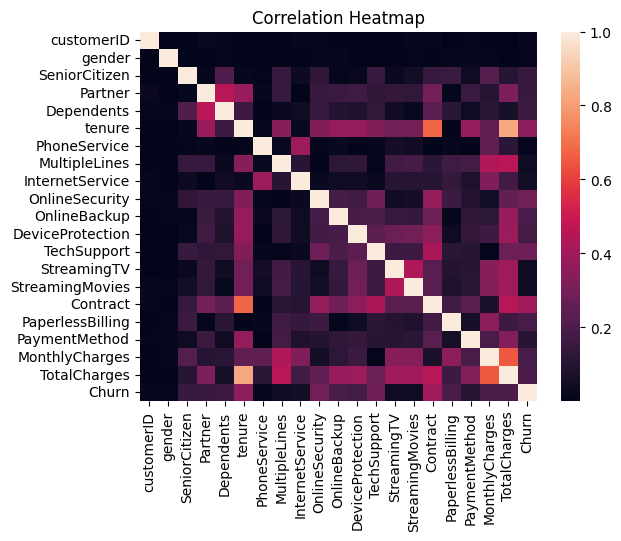

In [173]:
#Heatmap to find any correlations between the different features and the Churn.
sns.heatmap(df.corr().abs()) #Creating the heatmapa
plt.title("Correlation Heatmap")
plt.show()

Based on the heatmap, none of the features have a strong correlation to the Churn (all of the scores are below 0.5).

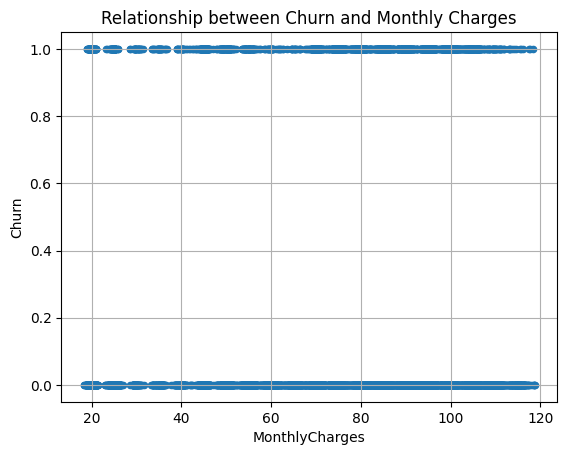

In [174]:
#Simple scatter plot to see if there is a correlation between Churn and Monthly Charges
df.plot.scatter(x = 'MonthlyCharges', y = 'Churn') #Showing a relationship between Churn and Monthly Charges
#Yes = 1, No = 0
plt.title("Relationship between Churn and Monthly Charges")
plt.grid()
plt.show()

As you can see, there is no correlation between monthly charges and Churn.

In [175]:
#Train Test Split
x = df.drop('Churn', axis = 1) #Separating the Churn column from the rest of the data.
y = df['Churn']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 1/3, random_state = 0) #Splitting the data into training and testing sets.
#Print statements
print(x_test)
print(y_test)
print(x_train)
print(y_train)

      customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
5561        3580       1              0        0           0       1   
5814         536       1              0        0           0      16   
2645        6030       0              0        0           0       1   
3983         915       1              0        0           0       1   
6438        2477       1              1        0           0       1   
...          ...     ...            ...      ...         ...     ...   
5809        5768       0              0        0           0       6   
557          791       1              0        0           0      38   
7002        6742       0              0        1           0      64   
1005        1971       0              1        1           0      53   
1180        3404       1              0        0           0      39   

      PhoneService  MultipleLines  InternetService  OnlineSecurity  \
5561             1              0                2               

In [176]:
#Preprocessing
sc = StandardScaler()
x_train = sc.fit_transform(x_train) #Transforming the training set into an array.
x_test = sc.transform(x_test) #Transforming the testing set into an array.
x_test

array([[ 0.0299547 ,  0.99235008, -0.43293958, ...,  0.39552464,
        -1.46816626, -0.99663269],
       [-1.47249393,  0.99235008, -0.43293958, ..., -0.54474894,
        -1.46983304, -0.86010754],
       [ 1.23921853, -1.00770889, -0.43293958, ..., -0.54474894,
        -1.49650152, -0.99700751],
       ...,
       [ 1.59064541, -1.00770889, -0.43293958, ..., -1.48502252,
         1.35702533,  1.99056041],
       [-0.76421082, -1.00770889,  2.30979115, ..., -0.54474894,
         1.03867041,  1.20629048],
       [-0.05691487,  0.99235008, -0.43293958, ..., -1.48502252,
        -0.4964337 , -0.13651546]])

In [177]:
#Logistic Regression
classifier = LogisticRegression() 
classifier.fit(x_train, y_train) #Creating the Logistic Regression model

LogisticRegression()

In [178]:
#Evaluating the Performance of the model
y_pred = classifier.predict(x_test) #Prediction model
accuracy = accuracy_score(y_test, y_pred) #Accuracy score
f1_score = f1_score(y_test, y_pred) #F1 score
recall_score = recall_score(y_test, y_pred) #Recall score
print("Accuracy: ", accuracy)
print("F1 Score: ", f1_score)
print("Recall score: ", recall_score)

Accuracy:  0.7986348122866894
F1 Score:  0.5866900175131349
Recall score:  0.536


Our logistic regression model is fairly accurate, however, our recall score is rather low sitting at a 0.53. This means that only 53%
of our data is relevant to the regression model.


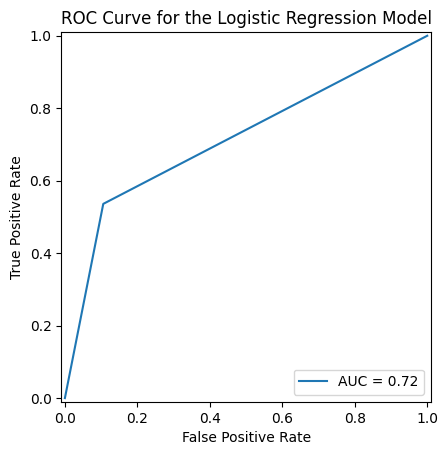

In [179]:
#ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
showcurve = metrics.RocCurveDisplay(fpr = fpr, tpr = tpr, roc_auc = roc_auc)
showcurve.plot()
plt.title("ROC Curve for the Logistic Regression Model")
plt.show()

Based on the ROC Curve and the AUC (area under curve) score being 0.72, our Logisitic Regression model cannot 100% accuratly predict the results based on the test dataset.

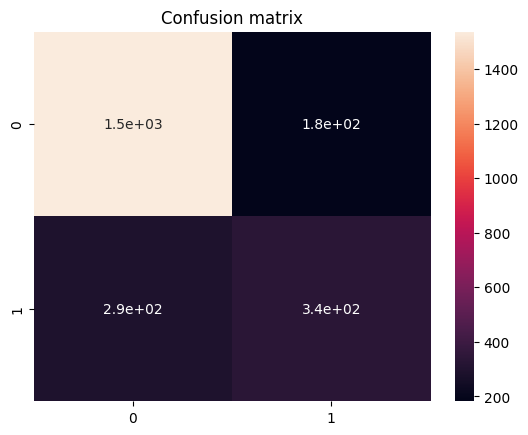

In [147]:
matrix = metrics.confusion_matrix(y_test, y_pred) #Creating the confusion matrix
sns.heatmap(matrix, annot = True) #Displaying the matrix as a heatmap.
plt.title("Confusion matrix")
plt.show()

From this confusion matrix, our regression model was able to correctly detect that the company was able to retain at least 1500 customers,
but lost at least 300 customers.